# 3D Metric Statistics Across Five Seeds


In [41]:
from pathlib import Path
import numpy as np
import nibabel as nib

# Get offline results directory
project = Path.cwd()
results_dir = project / "offline_results"
assert results_dir.is_dir(), f"Not found: {results_dir}"

SEEDS = [0, 1, 2, 3, 4]
ORGANS = {1: "Esophagus", 2: "Heart", 3: "Trachea", 4: "Aorta"}
SCAN_DIR = project / "data" / "segthor_part1" / "train"
HD_PERCENTILE = 95
results = {}
results_without_penalty = {}
results_with_penalty = {}
patient_penalties = {}


def maximum_distance_penalty(patient):
    # Stitched predictions use the original scan grid as in its header
    if patient not in patient_penalties:
        scan_path = SCAN_DIR / patient / f"{patient}.nii.gz"
        scan = nib.load(scan_path)
        assert len(scan.shape) == 3, f"Expected 3D scan: {scan_path}"

        spacing = np.asarray(scan.header.get_zooms(), dtype=float)
        units = scan.header.get_xyzt_units()[0]
        assert units in ("mm", "meter", "micron"), f"Unknown spatial units: {scan_path}"

        if units == "meter":
            spacing = spacing * 1000
        elif units == "micron":
            spacing = spacing / 1000
        assert np.all(np.isfinite(spacing) & (spacing > 0))
        
        # Full CT Scan diagonal computed as parallelepiped diagonal: sqrt(sum((scan shape * voxel spacing)**2))
        physical_size = np.asarray(scan.shape) * spacing
        patient_penalties[patient] = float(np.sqrt(np.sum(physical_size ** 2)))

    return patient_penalties[patient]


def load_offline_metrics(folder):
    """
    Load old or new 3D results into the notebook's existing input format.
    """
    dice = np.load(folder / "dice_3d_val.npy").astype(float)
    hd = np.load(folder / "hd_3d_val.npy").astype(float)
    patients = np.load(folder / "patients_val.npy")
    assert dice.ndim == 2 and dice.shape[1] == 5, f"Unexpected shape: {folder}"
    assert hd.shape == dice.shape and patients.shape == (len(dice),)
    assert len(set(patients.tolist())) == len(patients), "Duplicate patient IDs"

    fp_file = folder / "fp_3d_val.npy"
    fn_file = folder / "fn_3d_val.npy"
    assert fp_file.is_file() == fn_file.is_file(), f"Missing FP or FN file: {folder}"
    if fp_file.is_file():
        fp = np.load(fp_file)
        fn = np.load(fn_file)
        assert fp.shape == fn.shape == dice.shape
        assert fp.dtype == bool and fn.dtype == bool
        assert not np.any(fp & fn), f"Overlapping FP/FN flags: {folder}"
        # Undo saved one-empty penalties, so we are able to see results without the penalty
        hd[fp | fn] = np.nan

    # Assign both-empty foreground pairs HD=0 under the new policy
    both_empty = np.isnan(dice[:, 1:]) & (np.isnan(hd[:, 1:]) | (hd[:, 1:] == 0))
    hd[:, 1:][both_empty] = 0
    return dice, hd, patients


def statistics(values):
    values = np.asarray(values, dtype=float)
    valid = values[np.isfinite(values)]  # exclude undefined values, but keep real zeros (including Dice failures)
    if len(valid) == 0:
        return np.nan, np.nan, 0
    mean = np.mean(valid)
    std = np.std(valid, ddof=0)
    count = len(valid)
    return mean, std, count


def analyse_setting(setting, use_hd_nan_penalty=False): # without penalty, undefined HD values are excluded from the mean/std calculations
    # Rows are seeds, columns are organs, without background
    dice_per_seed = np.full((5, 4), np.nan)
    hd_per_seed = np.full((5, 4), np.nan)
    patient_sets = []
    penalty_counts = np.zeros((5, 4), dtype=int)

    if use_hd_nan_penalty:
        print("HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.")
    else:
        print("HD policy: exclude undefined HD values.")

    for seed in SEEDS:
        folder = results_dir / setting / f"ce_seed{seed}" / "metrics_3d"
        filenames = ["dice_3d_val.npy", "hd_3d_val.npy", "patients_val.npy"]
        missing = []
        for name in filenames:
            if not (folder / name).is_file():
                missing.append(name)
        if missing:
            print(f"{setting}, seed {seed}: missing {missing} is excluded.")
            continue

        dice, hd, patients = load_offline_metrics(folder)

        # Checks
        assert dice.ndim == 2 and dice.shape[1] == 5, f"Unexpected shape in {folder}"
        assert hd.shape == dice.shape and patients.shape == (len(dice),)
        assert len(set(patients.tolist())) == len(patients), "Duplicate patient IDs"

        patient_set = set(patients.tolist())
        if patient_sets and patient_set != patient_sets[0]:
            print(f"WARNING: {setting}, seed {seed}: different patients from other seeds.")
        patient_sets.append(patient_set)

        for class_id, organ in ORGANS.items():
            for row, patient in enumerate(patients):
                dice_value = dice[row, class_id]
                hd_value = hd[row, class_id]
                if not np.isfinite(dice_value) or not np.isfinite(hd_value):
                    print(f"{setting}, seed {seed}, {patient}, class {class_id} ({organ}): "
                          f"Dice={dice_value}, HD{HD_PERCENTILE}={hd_value}.")
                    if np.isnan(hd_value) and dice_value == 0:
                        print("  One mask is empty: organ not predicted if present in ground truth.")
                    elif np.isnan(hd_value) and np.isnan(dice_value):
                        print("  Both masks are empty (saved Dice and HD are NaN).")  # Never triggers unless there is a mistake in the ground truth, since all patients should have all four organs in 3D.

                if use_hd_nan_penalty and np.isnan(hd_value):
                    if np.isnan(dice_value):  # Dice is NaN when both masks are empty
                        hd_value = 0
                        print("  Both masks empty: HD set to 0 mm (no penalty).")  # Never triggers unless there is a mistake in the ground truth, since all patients should have all four organs in 3D.
                    elif dice_value == 0: # Dice=0 together with HD=NaN means exactly one mask is empty
                        hd_value = maximum_distance_penalty(str(patient))
                        penalty_counts[seed, class_id - 1] += 1
                        print(f"  HD NaN replaced with patient diagonal: {hd_value:.3f} mm.")

                hd[row, class_id] = hd_value
                if not np.isfinite(hd_value):
                    print("  HD excluded from mean/std.")
                if not np.isfinite(dice_value):
                    print("  Dice excluded from mean/std.")

            # Each seed contributes one patient-average score per organ
            dice_per_seed[seed, class_id - 1] = statistics(dice[:, class_id])[0]
            hd_per_seed[seed, class_id - 1] = statistics(hd[:, class_id])[0]

    # Each available organ has equal weight in the overall score for a seed
    overall_dice = np.full(5, np.nan)
    overall_hd = np.full(5, np.nan)
    for seed in SEEDS:
        overall_dice[seed] = statistics(dice_per_seed[seed])[0]
        overall_hd[seed] = statistics(hd_per_seed[seed])[0]
        dice_count = np.isfinite(dice_per_seed[seed]).sum()
        hd_count = np.isfinite(hd_per_seed[seed]).sum()
        if dice_count < 4 or hd_count < 4:
            print(f"{setting}, seed {seed}: overall uses {dice_count}/4 Dice organs "
                  f"and {hd_count}/4 HD organs.")

    results[setting] = {
        "dice": dice_per_seed,
        "hd": hd_per_seed,
        "overall_dice": overall_dice,
        "overall_hd": overall_hd,
        "patient_sets": patient_sets,
        "hd_nan_penalty": use_hd_nan_penalty,
        "penalty_counts": penalty_counts}

    # Keep both versions so later plots cannot silently use the wrong policy
    if use_hd_nan_penalty:
        results_with_penalty[setting] = results[setting]
    else:
        results_without_penalty[setting] = results[setting]

    print("\nPer-organ statistics across seed means:")
    print(f"{'Organ':<14} {'Dice mean':>10} {'Dice std':>10} {'seeds':>6} "
          f"{'HD{HD_PERCENTILE} mean mm':>14} {'HD{HD_PERCENTILE} std mm':>13} {'seeds':>6}")
    
    for class_id, organ in ORGANS.items():
        dice_mean, dice_std, dice_num = statistics(dice_per_seed[:, class_id - 1])
        hd_mean, hd_std, hd_num = statistics(hd_per_seed[:, class_id - 1])
        print(f"{organ:<14} {dice_mean:10.4f} {dice_std:10.4f} {dice_num:6d} "
              f"{hd_mean:14.4f} {hd_std:13.4f} {hd_num:6d}")


def print_overall(setting):
    setting_results = results[setting]
    print("Overall scores per seed (mean of available organ means):")
    for seed in SEEDS:
        print(f"Seed {seed}: Dice={setting_results['overall_dice'][seed]:.4f}, "
              f"HD{HD_PERCENTILE}={setting_results['overall_hd'][seed]:.4f} mm")
    for name, key in [("Dice", "overall_dice"), (f"HD{HD_PERCENTILE} (mm)", "overall_hd")]:
        mean, std, count = statistics(setting_results[key])
        print(f"{name}: mean={mean:.4f}, std={std:.4f}, "
              f"valid seeds={count}, invalid/missing seeds={5 - count}")


## No Modifications (Per-patient Minmax)

### Without penalty

In [42]:
analyse_setting("segthor_final")


HD policy: exclude undefined HD values.
segthor_final, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_final, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_final, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_final, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_final, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_final, seed 3, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is 

In [43]:
print_overall("segthor_final")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5620, HD95=20.2402 mm
Seed 1: Dice=0.5618, HD95=33.2152 mm
Seed 2: Dice=0.6149, HD95=24.7912 mm
Seed 3: Dice=0.3358, HD95=32.7268 mm
Seed 4: Dice=0.6232, HD95=22.1732 mm
Dice: mean=0.5396, std=0.1051, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=26.6293, std=5.3779, valid seeds=5, invalid/missing seeds=0


### With penalty

In [44]:
analyse_setting("segthor_final", use_hd_nan_penalty=True)

HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.
segthor_final, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 842.475 mm.
segthor_final, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 826.290 mm.
segthor_final, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 1023.474 mm.
segthor_final, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 785.471 mm.
segthor_final, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if pres

In [45]:
print_overall("segthor_final")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5620, HD95=230.0603 mm
Seed 1: Dice=0.5618, HD95=33.2152 mm
Seed 2: Dice=0.6149, HD95=24.7912 mm
Seed 3: Dice=0.3358, HD95=446.1237 mm
Seed 4: Dice=0.6232, HD95=22.1732 mm
Dice: mean=0.5396, std=0.1051, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=151.2727, std=167.1804, valid seeds=5, invalid/missing seeds=0


## B-Spline Interpolation

### Without penalty

In [46]:
analyse_setting("segthor_bspline")


HD policy: exclude undefined HD values.

Per-organ statistics across seed means:
Organ           Dice mean   Dice std  seeds HD{HD_PERCENTILE} mean mm HD{HD_PERCENTILE} std mm  seeds
Esophagus          0.4614     0.0252      5        24.8365       12.0898      5
Heart              0.8171     0.0366      5        35.8199       12.8672      5
Trachea            0.7197     0.0633      5        41.2502       11.9416      5
Aorta              0.6868     0.0264      5        26.8526        6.6482      5


In [47]:
print_overall("segthor_bspline")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.6894, HD95=25.1090 mm
Seed 1: Dice=0.6930, HD95=31.2958 mm
Seed 2: Dice=0.6785, HD95=35.7529 mm
Seed 3: Dice=0.6892, HD95=36.2407 mm
Seed 4: Dice=0.6063, HD95=32.5507 mm
Dice: mean=0.6713, std=0.0328, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=32.1898, std=4.0043, valid seeds=5, invalid/missing seeds=0


### With penalty

In [48]:
analyse_setting("segthor_bspline", use_hd_nan_penalty=True)

HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.

Per-organ statistics across seed means:
Organ           Dice mean   Dice std  seeds HD{HD_PERCENTILE} mean mm HD{HD_PERCENTILE} std mm  seeds
Esophagus          0.4614     0.0252      5        24.8365       12.0898      5
Heart              0.8171     0.0366      5        35.8199       12.8672      5
Trachea            0.7197     0.0633      5        41.2502       11.9416      5
Aorta              0.6868     0.0264      5        26.8526        6.6482      5


In [49]:
print_overall("segthor_bspline")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.6894, HD95=25.1090 mm
Seed 1: Dice=0.6930, HD95=31.2958 mm
Seed 2: Dice=0.6785, HD95=35.7529 mm
Seed 3: Dice=0.6892, HD95=36.2407 mm
Seed 4: Dice=0.6063, HD95=32.5507 mm
Dice: mean=0.6713, std=0.0328, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=32.1898, std=4.0043, valid seeds=5, invalid/missing seeds=0


## Clipping

### Without penalty

In [50]:
analyse_setting("segthor_clip")


HD policy: exclude undefined HD values.
segthor_clip, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_clip, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_clip, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_clip, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_clip, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_clip, seed 0: overall uses 4/4 Dice organs and 3/4 HD organs.

Per-organ statistics acr

In [51]:
print_overall("segthor_clip")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5736, HD95=15.2336 mm
Seed 1: Dice=0.7154, HD95=14.8818 mm
Seed 2: Dice=0.6153, HD95=22.5597 mm
Seed 3: Dice=0.7123, HD95=19.8957 mm
Seed 4: Dice=0.6697, HD95=18.8903 mm
Dice: mean=0.6572, std=0.0553, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=18.2922, std=2.9026, valid seeds=5, invalid/missing seeds=0


### With penalty

In [52]:
analyse_setting("segthor_clip", use_hd_nan_penalty=True)

HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.
segthor_clip, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 842.475 mm.
segthor_clip, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 826.290 mm.
segthor_clip, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 1023.474 mm.
segthor_clip, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 785.471 mm.
segthor_clip, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present i

In [53]:
print_overall("segthor_clip")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5736, HD95=226.3054 mm
Seed 1: Dice=0.7154, HD95=14.8818 mm
Seed 2: Dice=0.6153, HD95=22.5597 mm
Seed 3: Dice=0.7123, HD95=19.8957 mm
Seed 4: Dice=0.6697, HD95=18.8903 mm
Dice: mean=0.6572, std=0.0553, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=60.5066, std=82.9361, valid seeds=5, invalid/missing seeds=0


## Whole-dataset Minmax

### Without penalty

In [54]:
analyse_setting("segthor_minmax_dataset")


HD policy: exclude undefined HD values.
segthor_minmax_dataset, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_minmax_dataset, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_minmax_dataset, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_minmax_dataset, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_minmax_dataset, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_minmax_dataset, seed 3, Patient_01, c

segthor_minmax_dataset, seed 0: overall uses 4/4 Dice organs and 3/4 HD organs.
segthor_minmax_dataset, seed 3: overall uses 4/4 Dice organs and 2/4 HD organs.

Per-organ statistics across seed means:
Organ           Dice mean   Dice std  seeds HD{HD_PERCENTILE} mean mm HD{HD_PERCENTILE} std mm  seeds
Esophagus          0.2483     0.2104      5        15.8470        3.4771      3
Heart              0.8912     0.0081      5        22.7872       12.4371      5
Trachea            0.4563     0.3479      5        25.6295        5.3254      4
Aorta              0.7028     0.0375      5        22.0577        8.3773      5


In [55]:
print_overall("segthor_minmax_dataset")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5981, HD95=22.6414 mm
Seed 1: Dice=0.4935, HD95=26.5295 mm
Seed 2: Dice=0.7022, HD95=21.3008 mm
Seed 3: Dice=0.3835, HD95=24.5978 mm
Seed 4: Dice=0.6959, HD95=16.4606 mm
Dice: mean=0.5747, std=0.1222, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=22.3060, std=3.4171, valid seeds=5, invalid/missing seeds=0


### With penalty

In [56]:
analyse_setting("segthor_minmax_dataset", use_hd_nan_penalty=True)


HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.
segthor_minmax_dataset, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 842.475 mm.
segthor_minmax_dataset, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 826.290 mm.
segthor_minmax_dataset, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 1023.474 mm.
segthor_minmax_dataset, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 785.471 mm.
segthor_minmax_dataset, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  O

In [57]:
print_overall("segthor_minmax_dataset")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5981, HD95=231.8612 mm
Seed 1: Dice=0.4935, HD95=26.5295 mm
Seed 2: Dice=0.7022, HD95=21.3008 mm
Seed 3: Dice=0.3835, HD95=442.0592 mm
Seed 4: Dice=0.6959, HD95=16.4606 mm
Dice: mean=0.5747, std=0.1222, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=147.6423, std=168.2933, valid seeds=5, invalid/missing seeds=0


## Per-patient Z-scoring

### Without penalty

In [58]:
analyse_setting("segthor_zscore_patient")


HD policy: exclude undefined HD values.
segthor_zscore_patient, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_patient, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_patient, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_patient, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_patient, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_patient, seed 3, Patient_01, c

In [59]:
print_overall("segthor_zscore_patient")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.6001, HD95=16.6344 mm
Seed 1: Dice=0.7105, HD95=30.3789 mm
Seed 2: Dice=0.6529, HD95=29.6494 mm
Seed 3: Dice=0.3764, HD95=25.3153 mm
Seed 4: Dice=0.7216, HD95=15.7804 mm
Dice: mean=0.6123, std=0.1257, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=23.5517, std=6.2473, valid seeds=5, invalid/missing seeds=0


### With penalty

In [60]:
analyse_setting("segthor_zscore_patient", use_hd_nan_penalty=True)


HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.
segthor_zscore_patient, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 842.475 mm.
segthor_zscore_patient, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 826.290 mm.
segthor_zscore_patient, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 1023.474 mm.
segthor_zscore_patient, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 785.471 mm.
segthor_zscore_patient, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  O

In [61]:
print_overall("segthor_zscore_patient")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.6001, HD95=227.3560 mm
Seed 1: Dice=0.7105, HD95=30.3789 mm
Seed 2: Dice=0.6529, HD95=29.6494 mm
Seed 3: Dice=0.3764, HD95=442.4180 mm
Seed 4: Dice=0.7216, HD95=15.7804 mm
Dice: mean=0.6123, std=0.1257, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=149.1165, std=166.3110, valid seeds=5, invalid/missing seeds=0


## Whole-dataset Z-scoring

### Without penalty

In [62]:
analyse_setting("segthor_zscore_dataset")


HD policy: exclude undefined HD values.
segthor_zscore_dataset, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_dataset, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_dataset, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_dataset, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_dataset, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD excluded from mean/std.
segthor_zscore_dataset, seed 3, Patient_01, c

In [63]:
print_overall("segthor_zscore_dataset")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5916, HD95=18.3959 mm
Seed 1: Dice=0.7286, HD95=24.5149 mm
Seed 2: Dice=0.6523, HD95=43.3552 mm
Seed 3: Dice=0.3659, HD95=26.3279 mm
Seed 4: Dice=0.6153, HD95=20.0888 mm
Dice: mean=0.5907, std=0.1216, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=26.5365, std=8.8864, valid seeds=5, invalid/missing seeds=0


### With penalty

In [64]:
analyse_setting("segthor_zscore_dataset", use_hd_nan_penalty=True)

HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.
segthor_zscore_dataset, seed 0, Patient_01, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 842.475 mm.
segthor_zscore_dataset, seed 0, Patient_08, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 826.290 mm.
segthor_zscore_dataset, seed 0, Patient_11, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 1023.474 mm.
segthor_zscore_dataset, seed 0, Patient_12, class 1 (Esophagus): Dice=0.0, HD95=nan.
  One mask is empty: organ not predicted if present in ground truth.
  HD NaN replaced with patient diagonal: 785.471 mm.
segthor_zscore_dataset, seed 0, Patient_16, class 1 (Esophagus): Dice=0.0, HD95=nan.
  O

In [65]:
print_overall("segthor_zscore_dataset")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.5916, HD95=228.6771 mm
Seed 1: Dice=0.7286, HD95=24.5149 mm
Seed 2: Dice=0.6523, HD95=43.3552 mm
Seed 3: Dice=0.3659, HD95=442.9243 mm
Seed 4: Dice=0.6153, HD95=20.0888 mm
Dice: mean=0.5907, std=0.1216, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=151.9120, std=164.9078, valid seeds=5, invalid/missing seeds=0


## Clipping + B-Spline + Per-patient Z-scoring 

### Without penalty

In [66]:
analyse_setting("segthor_clip_zscore_patient_bspline")


HD policy: exclude undefined HD values.



Per-organ statistics across seed means:
Organ           Dice mean   Dice std  seeds HD{HD_PERCENTILE} mean mm HD{HD_PERCENTILE} std mm  seeds
Esophagus          0.4743     0.0253      5        15.4942        1.8921      5
Heart              0.8807     0.0191      5        21.8894       10.8302      5
Trachea            0.8265     0.0107      5        11.8407        2.8231      5
Aorta              0.7481     0.0193      5        25.5573        7.0809      5


In [67]:
print_overall("segthor_clip_zscore_patient_bspline")


Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.7514, HD95=13.0402 mm
Seed 1: Dice=0.7351, HD95=21.3678 mm
Seed 2: Dice=0.7105, HD95=21.8026 mm
Seed 3: Dice=0.7250, HD95=21.9336 mm
Seed 4: Dice=0.7401, HD95=15.3328 mm
Dice: mean=0.7324, std=0.0139, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=18.6954, std=3.7569, valid seeds=5, invalid/missing seeds=0


### With penalty

In [68]:
analyse_setting("segthor_clip_zscore_patient_bspline", use_hd_nan_penalty=True)

HD policy: one-empty pairs get the scan diagonal, while both-empty pairs get zero.

Per-organ statistics across seed means:
Organ           Dice mean   Dice std  seeds HD{HD_PERCENTILE} mean mm HD{HD_PERCENTILE} std mm  seeds
Esophagus          0.4743     0.0253      5        15.4942        1.8921      5
Heart              0.8807     0.0191      5        21.8894       10.8302      5
Trachea            0.8265     0.0107      5        11.8407        2.8231      5
Aorta              0.7481     0.0193      5        25.5573        7.0809      5


In [69]:
print_overall("segthor_clip_zscore_patient_bspline")

Overall scores per seed (mean of available organ means):
Seed 0: Dice=0.7514, HD95=13.0402 mm
Seed 1: Dice=0.7351, HD95=21.3678 mm
Seed 2: Dice=0.7105, HD95=21.8026 mm
Seed 3: Dice=0.7250, HD95=21.9336 mm
Seed 4: Dice=0.7401, HD95=15.3328 mm
Dice: mean=0.7324, std=0.0139, valid seeds=5, invalid/missing seeds=0
HD95 (mm): mean=18.6954, std=3.7569, valid seeds=5, invalid/missing seeds=0


## Comparison Across Settings

### Without penalty

In [70]:
print(f"{'Setting':<42} {'Dice mean/std':<24} {f'HD{HD_PERCENTILE} mean/std (mm)':<26} {'valid seeds D/H'}")
reference_patients = None
for setting, values in results_without_penalty.items():
    dm, ds, dn = statistics(values["overall_dice"])
    hm, hs, hn = statistics(values["overall_hd"])
    print(f"{setting:<42} {dm:.4f} ± {ds:.4f}          {hm:.4f} ± {hs:.4f}              {dn}/{hn}")
    for patients in values["patient_sets"]:
        if reference_patients is None:
            reference_patients = patients
        elif patients != reference_patients:
            print(f"  WARNING: {setting} uses different patients from the first setting.")
            break


Setting                                    Dice mean/std            HD95 mean/std (mm)         valid seeds D/H
segthor_final                              0.5396 ± 0.1051          26.6293 ± 5.3779              5/5
segthor_bspline                            0.6713 ± 0.0328          32.1898 ± 4.0043              5/5
segthor_clip                               0.6572 ± 0.0553          18.2922 ± 2.9026              5/5
segthor_minmax_dataset                     0.5747 ± 0.1222          22.3060 ± 3.4171              5/5
segthor_zscore_patient                     0.6123 ± 0.1257          23.5517 ± 6.2473              5/5
segthor_zscore_dataset                     0.5907 ± 0.1216          26.5365 ± 8.8864              5/5
segthor_clip_zscore_patient_bspline        0.7324 ± 0.0139          18.6954 ± 3.7569              5/5


### With penalty

In [71]:
print(f"{'Setting':<42} {'Dice mean/std':<24} {f'HD{HD_PERCENTILE} mean/std (mm)':<26} {'valid seeds D/H'}")
reference_patients = None
for setting, values in results_with_penalty.items():
    dm, ds, dn = statistics(values["overall_dice"])
    hm, hs, hn = statistics(values["overall_hd"])
    print(f"{setting:<42} {dm:.4f} ± {ds:.4f}          {hm:.4f} ± {hs:.4f}              {dn}/{hn}")
    for patients in values["patient_sets"]:
        if reference_patients is None:
            reference_patients = patients
        elif patients != reference_patients:
            print(f"  WARNING: {setting} uses different patients from the first setting.")
            break


Setting                                    Dice mean/std            HD95 mean/std (mm)         valid seeds D/H
segthor_final                              0.5396 ± 0.1051          151.2727 ± 167.1804              5/5
segthor_bspline                            0.6713 ± 0.0328          32.1898 ± 4.0043              5/5
segthor_clip                               0.6572 ± 0.0553          60.5066 ± 82.9361              5/5
segthor_minmax_dataset                     0.5747 ± 0.1222          147.6423 ± 168.2933              5/5
segthor_zscore_patient                     0.6123 ± 0.1257          149.1165 ± 166.3110              5/5
segthor_zscore_dataset                     0.5907 ± 0.1216          151.9120 ± 164.9078              5/5
segthor_clip_zscore_patient_bspline        0.7324 ± 0.0139          18.6954 ± 3.7569              5/5


# Plots Comparing Dice and HD

In [72]:
# Folder name -> display name
names = {
    "segthor_final": "Baseline",
    "segthor_bspline": "B-Spline",
    "segthor_clip": "Clipping",
    "segthor_minmax_dataset": "Dataset-level Min-Max",
    "segthor_zscore_patient": "Patient-level Z-Score",
    "segthor_zscore_dataset": "Dataset-level Z-Score",
    "segthor_clip_zscore_patient_bspline": "Clipping + Patient-level Z-Score + B-Spline",
}
# Falls back to the folder name if not in the dict
label = lambda s: names.get(s, s)   

setting_colors = {
    "segthor_final": "tab:blue",
    "segthor_minmax_dataset": "tab:orange",
    "segthor_zscore_patient": "tab:green",
    "segthor_zscore_dataset": "tab:red",
    "segthor_clip": "tab:purple",
    "segthor_bspline": "tab:pink",
    "segthor_clip_zscore_patient_bspline": "tab:brown",
}

## Without penalty

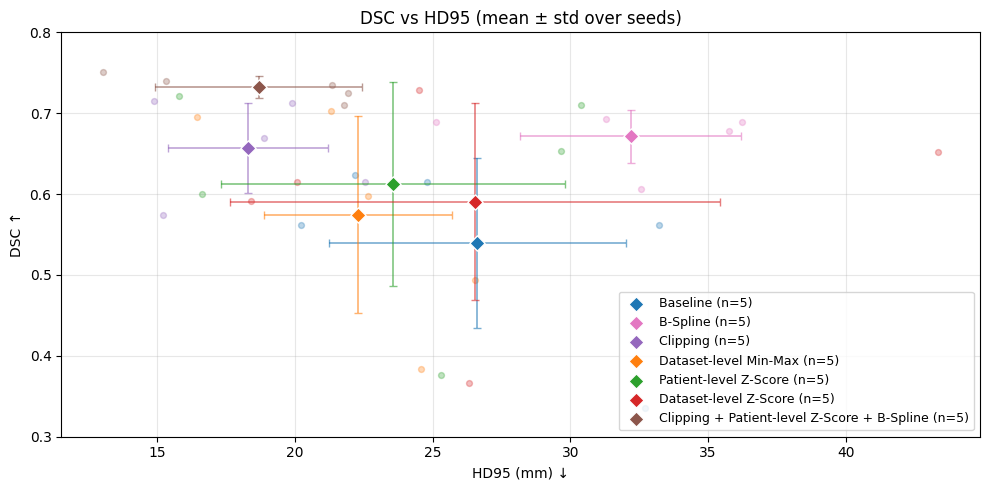

In [73]:
import matplotlib.pyplot as plt

def draw(ax, settings, get_dice, get_hd):
    for i, s in enumerate(settings):
        d, h = get_dice(results_without_penalty[s]), get_hd(results_without_penalty[s])
        ok = np.isfinite(d) & np.isfinite(h)      # same seeds for both metrics
        if not ok.any():
            continue
        dm, ds, _ = statistics(d[ok])
        hm, hs, _ = statistics(h[ok])
        c = setting_colors[s]
        ax.scatter(h[ok], d[ok], color=c, alpha=0.3, s=18, zorder=2)   # seeds
        ax.errorbar(hm, dm, xerr=hs, yerr=ds, fmt="none", ecolor=c, elinewidth=1.2, capsize=3, alpha=0.6, zorder=3) # spread
        ax.scatter(hm, dm, marker="D", s=60, color=c, edgecolors="white", linewidths=1, zorder=4, label=f"{label(s)} (n={ok.sum()})")  # mean
    
    ax.set_xlabel(f"HD{HD_PERCENTILE} (mm) ↓")
    ax.set_ylabel("DSC ↑")
    ax.grid(alpha=0.3)

settings = list(results_without_penalty.keys())

# Overall scatter
# Organ-averaged score per seed
fig, ax = plt.subplots(figsize=(10, 5))
draw(ax, settings, lambda r: r["overall_dice"], lambda r: r["overall_hd"])
ax.set_title(f"DSC vs HD{HD_PERCENTILE} (mean ± std over seeds)")
ax.legend(fontsize=9)
ax.set_ylim(0.3, 0.8)
plt.tight_layout()
plt.show()


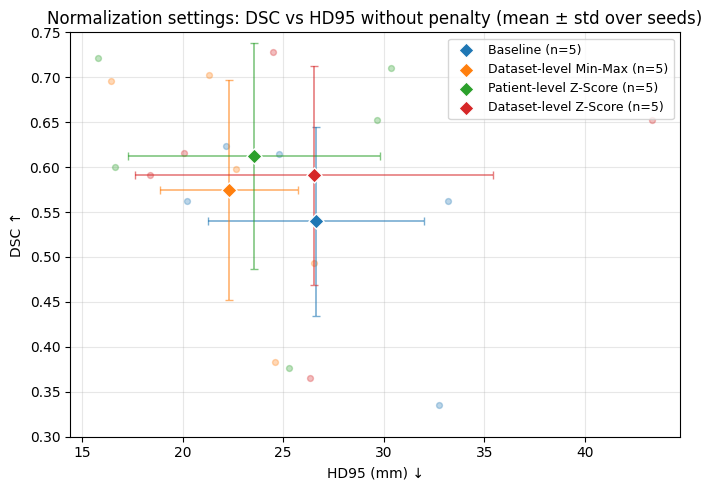

In [74]:
normalization_settings = [
    "segthor_final",
    "segthor_minmax_dataset",
    "segthor_zscore_patient",
    "segthor_zscore_dataset",
]

fig, ax = plt.subplots(figsize=(7, 5))
draw(ax, normalization_settings,
    lambda r: r["overall_dice"],
    lambda r: r["overall_hd"])

ax.set_title(f"Normalization settings: DSC vs HD{HD_PERCENTILE} without penalty (mean ± std over seeds)")
ax.legend(fontsize=9)
ax.set_ylim(0.3, 0.75)
plt.tight_layout()
plt.show()

## With penalty

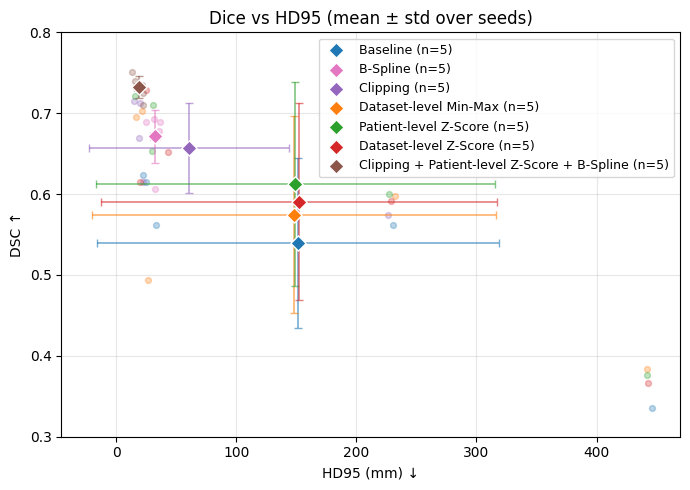

In [75]:
import matplotlib.pyplot as plt

settings = list(results_with_penalty.keys())

def draw(ax, settings, get_dice, get_hd):
    for i, s in enumerate(settings):
        d, h = get_dice(results_with_penalty[s]), get_hd(results_with_penalty[s])
        ok = np.isfinite(d) & np.isfinite(h)      # same seeds for both metrics
        if not ok.any():
            continue
        dm, ds, _ = statistics(d[ok])
        hm, hs, _ = statistics(h[ok])
        c = setting_colors[s]
        ax.scatter(h[ok], d[ok], color=c, alpha=0.3, s=18, zorder=2)   # seeds
        ax.errorbar(hm, dm, xerr=hs, yerr=ds, fmt="none", ecolor=c, elinewidth=1.2, capsize=3, alpha=0.6, zorder=3) # spread
        ax.scatter(hm, dm, marker="D", s=60, color=c, edgecolors="white", linewidths=1, zorder=4, label=f"{label(s)} (n={ok.sum()})")  # mean
    
    ax.set_xlabel(f"HD{HD_PERCENTILE} (mm) ↓")
    ax.set_ylabel("DSC ↑")
    ax.grid(alpha=0.3)

# Overall scatter
# Organ-averaged score per seed
fig, ax = plt.subplots(figsize=(7, 5))
draw(ax, settings, lambda r: r["overall_dice"], lambda r: r["overall_hd"])
ax.set_title(f"Dice vs HD{HD_PERCENTILE} (mean ± std over seeds)")
ax.legend(fontsize=9)
ax.set_ylim(0.3, 0.8)
plt.tight_layout()
plt.show()


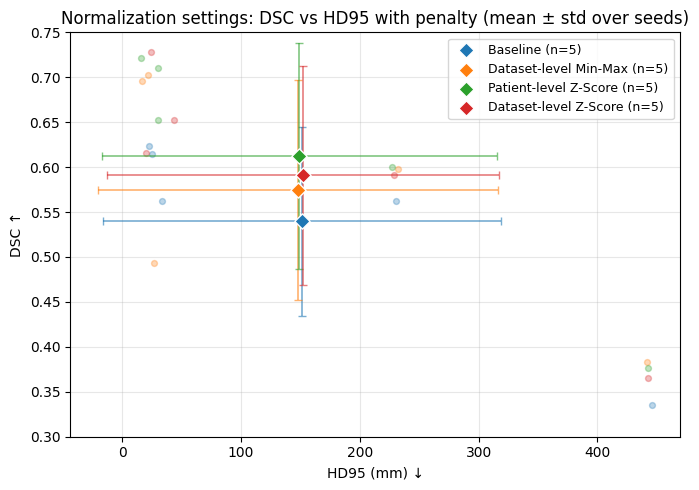

In [76]:
normalization_settings = [
    "segthor_final",
    "segthor_minmax_dataset",
    "segthor_zscore_patient",
    "segthor_zscore_dataset",
]

fig, ax = plt.subplots(figsize=(7, 5))
draw(ax, normalization_settings,
    lambda r: r["overall_dice"],
    lambda r: r["overall_hd"])

ax.set_title(f"Normalization settings: DSC vs HD{HD_PERCENTILE} with penalty (mean ± std over seeds)")
ax.legend(fontsize=9)
ax.set_ylim(0.3, 0.75)
plt.tight_layout()
plt.show()

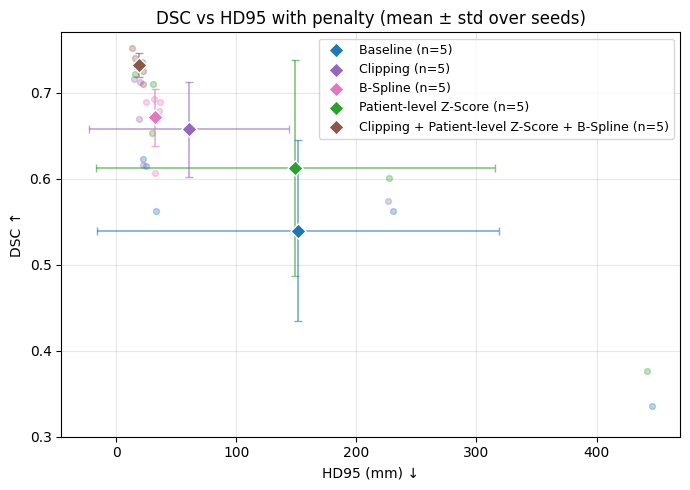

In [77]:
individual_settings = [
    "segthor_final",
    "segthor_clip",
    "segthor_bspline",
    "segthor_zscore_patient",
    "segthor_clip_zscore_patient_bspline"
]

fig, ax = plt.subplots(figsize=(7, 5))
draw(ax, individual_settings,
    lambda r: r["overall_dice"],
    lambda r: r["overall_hd"])

ax.set_title(f"DSC vs HD{HD_PERCENTILE} with penalty (mean ± std over seeds)")
ax.legend(fontsize=9)
ax.set_ylim(0.3, 0.77)
plt.tight_layout()
plt.show()

# Plot Comparing Classes for the Best Setting

Best mean overall Dice: 0.7324; with HD penalty.


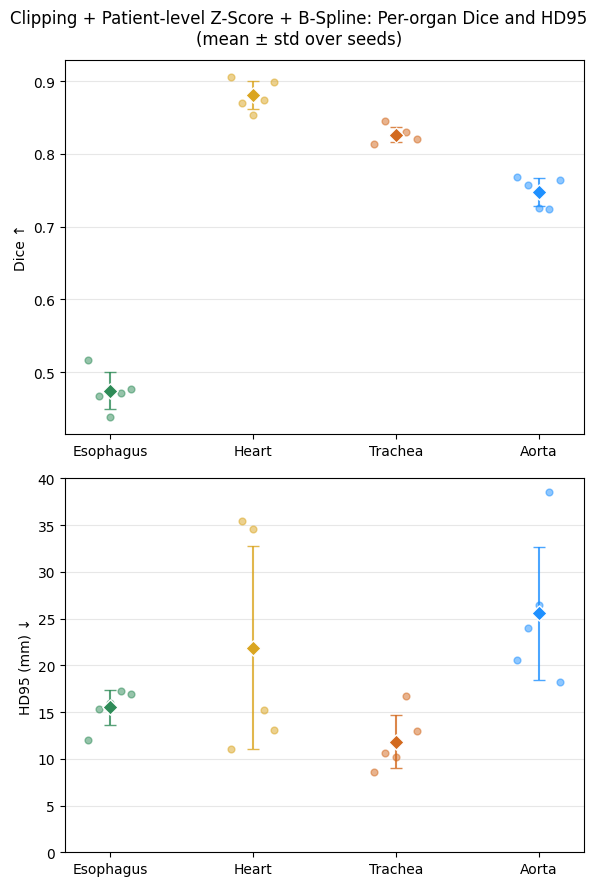

In [78]:
import matplotlib.pyplot as plt

def plot_best_classes(use_hd_nan_penalty=False):
    # Select the best setting by mean overall Dice across available seeds
    data = results_with_penalty if use_hd_nan_penalty else results_without_penalty
    policy = "with HD penalty" if use_hd_nan_penalty else "without HD penalty"

    best_setting = max(data, key=lambda setting: statistics(data[setting]["overall_dice"])[0])
    best_score = statistics(data[best_setting]["overall_dice"])[0]

    colors = ["seagreen", "goldenrod", "chocolate", "dodgerblue"]
    organs = list(ORGANS.values())
    offsets = np.linspace(-0.15, 0.15, len(SEEDS)) # fixed jitter so every seed is visible

    fig, axes = plt.subplots(2, 1, figsize=(6, 9))
    for ax, metric, ylabel in zip(axes, ["dice", "hd"],
                                  ["Dice ↑", f"HD{HD_PERCENTILE} (mm) ↓"]):
        for j, organ in enumerate(organs):
            v = data[best_setting][metric][:, j]
            ok = np.isfinite(v)
            if not ok.any():
                continue
            m, s, _ = statistics(v[ok])
            c = colors[j]
            ax.scatter(j + offsets[ok], v[ok], color=c, alpha=0.5, s=24, zorder=2)   # seeds
            ax.scatter(j, m, marker="D", s=60, color=c, edgecolors="white", linewidths=1,
                                   zorder=4, label=f"{organ} (n={ok.sum()})")
            ax.errorbar(j, m, yerr=s, fmt="none", color=c, alpha=0.8, ms=7, capsize=4, zorder=3)   # mean ± std
            
        ax.set_xticks(range(len(organs)))
        ax.set_xticklabels(organs)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
    
    axes[1].set_ylim(bottom=0)

    fig.suptitle(f"{label(best_setting)}: Per-organ Dice and HD{HD_PERCENTILE}\n"
                 f"(mean ± std over seeds)")
    print(f"Best mean overall Dice: {best_score:.4f}; {policy}.")
    fig.tight_layout()
    plt.show()

plot_best_classes(use_hd_nan_penalty=True)


Best mean overall DSC: 0.7324; with HD penalty.


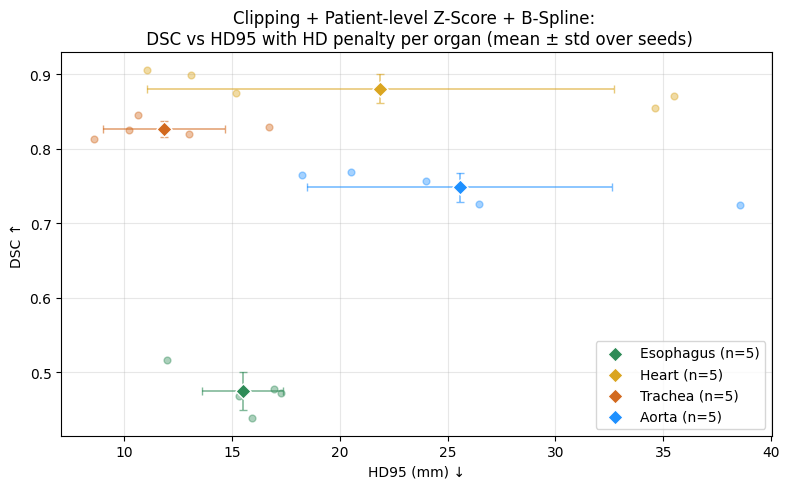

In [79]:
import matplotlib.pyplot as plt

def plot_best_classes(use_hd_nan_penalty=False):
    # Select the best setting by mean overall Dice across available seeds
    data = results_with_penalty if use_hd_nan_penalty else results_without_penalty
    policy = "with HD penalty" if use_hd_nan_penalty else "without HD penalty"

    best_setting = max(data, key=lambda setting: statistics(data[setting]["overall_dice"])[0])
    best_score = statistics(data[best_setting]["overall_dice"])[0]
    best = data[best_setting]
    
    colors = ["seagreen", "goldenrod", "chocolate", "dodgerblue"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for j, organ in enumerate(ORGANS.values()):
        d, h = best["dice"][:, j], best["hd"][:, j]
        ok = np.isfinite(d) & np.isfinite(h)   # same seeds for both metrics
        if not ok.any():
            continue
        dm, ds, _ = statistics(d[ok])
        hm, hs, _ = statistics(h[ok])
        c = colors[j]
        ax.scatter(h[ok], d[ok], color=c, alpha=0.4, s=24, zorder=2)  # seeds
        ax.errorbar(hm, dm, xerr=hs, yerr=ds, fmt="none", ecolor=c, elinewidth=1.2,
                    capsize=3, alpha=0.6, zorder=3)   # std
        ax.scatter(hm, dm, marker="D", s=60, color=c, edgecolors="white", linewidths=1,
                   zorder=4, label=f"{organ} (n={ok.sum()})")   # mean

    ax.set_xlabel(f"HD{HD_PERCENTILE} (mm) ↓")
    ax.set_ylabel("DSC ↑")
    ax.grid(alpha=0.3)
    ax.set_title(f"{label(best_setting)}: \n DSC vs HD{HD_PERCENTILE} {policy} per organ (mean ± std over seeds)")
    ax.legend(fontsize=10)
    print(f"Best mean overall DSC: {best_score:.4f}; {policy}.")
    plt.tight_layout()
    plt.show()

plot_best_classes(use_hd_nan_penalty=True)

## Performance Across Patients per Class for Best Setting


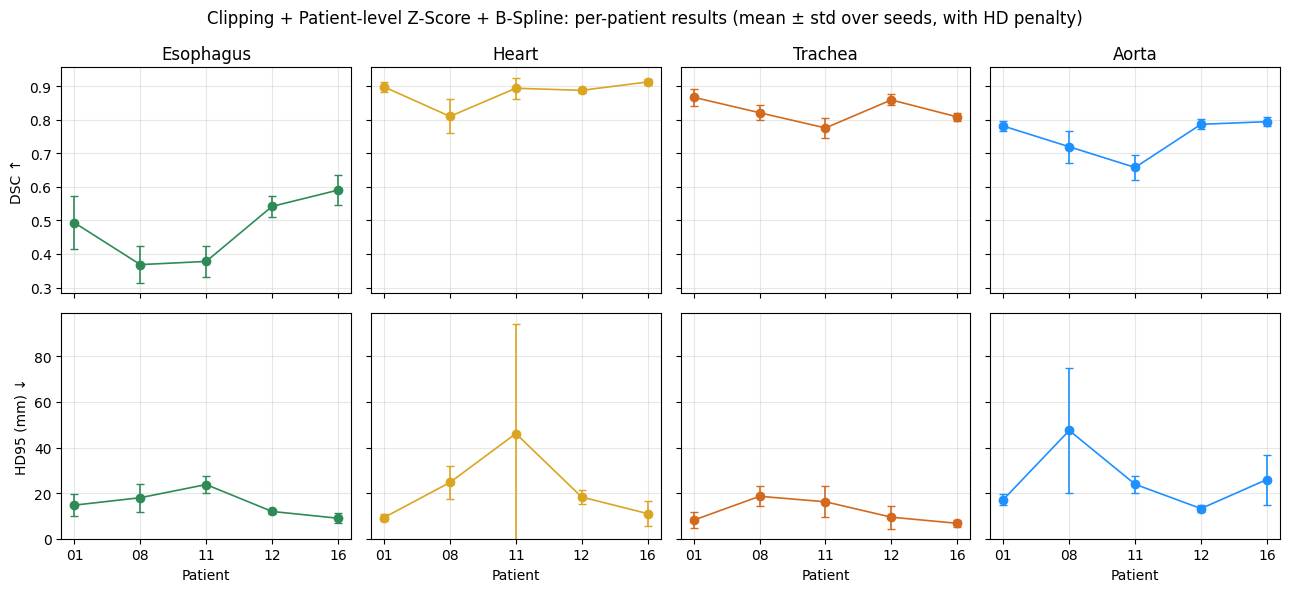

In [80]:
import matplotlib.pyplot as plt

def plot_patients(use_hd_nan_penalty=False, setting="segthor_clip_zscore_patient_bspline"):
    dice_seeds, hd_seeds, reference = [], [], None
    for seed in SEEDS:
        folder = results_dir / setting / f"ce_seed{seed}" / "metrics_3d"
        dice, hd, patients = load_offline_metrics(folder)
        assert len(set(patients)) == len(patients), "Duplicate patient IDs."
        order = np.argsort(patients)   # sorted by ID, matches patients across seeds
        patients = patients[order]
        dice = dice[order][:, 1:]   # drop background
        hd = hd[order][:, 1:]
        if reference is None:
            reference = patients
        assert np.array_equal(patients, reference), "All seeds must use the same validation patients."

        if use_hd_nan_penalty:  # same empty-mask policy as analyse_setting()
            missing = np.isnan(hd)
            hd[missing & np.isnan(dice)] = 0
            for r, c in np.argwhere(missing & (dice == 0)):
                hd[r, c] = maximum_distance_penalty(str(patients[r]))
        dice_seeds.append(dice)
        hd_seeds.append(hd)

    # Mean and std over seeds for every patient and organ
    scores = {}
    for metric, values in [("dice", np.array(dice_seeds)), ("hd", np.array(hd_seeds))]:
        mean = np.full(values.shape[1:], np.nan)  # values: (seeds, patients, organs)
        std = np.full_like(mean, np.nan)
        for p, o in np.ndindex(mean.shape):
            mean[p, o], std[p, o], _ = statistics(values[:, p, o])
        scores[metric] = {"mean": mean, "std": std}
        bad = (~np.isfinite(values)).sum()
        if bad:
            print(f"{metric}: {bad} of {values.size} values nonfinite, excluded.")

    x = np.arange(len(reference))
    names = [str(p).replace("Patient_", "") for p in reference]
    colors = ["seagreen", "goldenrod", "chocolate", "dodgerblue"]
    organs = list(ORGANS.values())

    fig, axes = plt.subplots(2, len(organs), figsize=(13, 6), sharex=True, sharey="row")
    for r, (metric, ylabel) in enumerate([("dice", "DSC ↑"), ("hd", f"HD{HD_PERCENTILE} (mm) ↓")]):
        for j, organ in enumerate(organs):
            ax = axes[r, j]
            ax.errorbar(x, scores[metric]["mean"][:, j], yerr=scores[metric]["std"][:, j],
                        fmt="o-", color=colors[j], ms=6, lw=1.2, elinewidth=1.2, capsize=3)
            ax.grid(alpha=0.3)
            if r == 0:
                ax.set_title(organ)
            if j == 0:
                ax.set_ylabel(ylabel)
            if r == 1:
                ax.set_xlabel("Patient")
    
    axes[1, 0].set_ylim(bottom=0)  # HD >= 0; whiskers below are clipped
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(names)

    policy = "with HD penalty" if use_hd_nan_penalty else "without HD penalty"
    fig.suptitle(f"{label(setting)}: per-patient results (mean ± std over seeds, {policy})")
    fig.tight_layout()
    plt.show()

    scores["patients"] = reference
    return scores

patient_comparison = plot_patients(use_hd_nan_penalty=True)